In [1]:
import timm
import torch
import fastai   

print(timm.__version__)
print(torch.__version__)
print(fastai.__version__)



1.0.12
2.5.1+cu124
2.7.18


## Load Model and Transforms

In [2]:
from PIL import Image
from urllib.request import urlopen


model_name = "hf_hub:timm/tf_mobilenetv3_large_100.in1k"
model = timm.create_model(model_name, pretrained=True, num_classes=0).eval()
model = model.to("cuda")

data_config = timm.data.resolve_model_data_config(model)
transforms = timm.data.create_transform(**data_config, is_training=False)



## Get Embeddings

In [3]:
img = Image.open(
    urlopen(
        "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/beignets-task-guide.png"
    )
)

with torch.inference_mode():
    output = model(transforms(img).unsqueeze(0).to("cuda"))

In [4]:
output.shape

torch.Size([1, 1280])

In [5]:
def get_batch_embeddings(image_dir, batch_size=32):
    """
    Get embeddings for all images in a directory using batch processing
    
    Args:
        image_dir (str): Path to directory containing images
        batch_size (int): Number of images to process at once
        
    Returns:
        torch.Tensor: Embeddings for all images (n_images x embedding_dim)
    """
    from pathlib import Path
    import torch
    from PIL import Image
    from tqdm.auto import tqdm
    
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        image_files.extend(Path(image_dir).glob(f'*{ext}'))
    
    all_embeddings = []
    
    for i in tqdm(range(0, len(image_files), batch_size), desc="Processing images"):
        batch_files = image_files[i:i + batch_size]
        batch_images = []
        
        # Load and transform each image in the batch
        for img_path in batch_files:
            img = Image.open(img_path)
            img_tensor = transforms(img)
            batch_images.append(img_tensor)
            
        # Stack batch and get embeddings
        batch_tensor = torch.stack(batch_images)
        
        with torch.inference_mode():
            batch_embeddings = model(batch_tensor.to("cuda"))
            
        all_embeddings.append(batch_embeddings)
    
    # Concatenate all batches
    return torch.cat(all_embeddings, dim=0)


embeddings = get_batch_embeddings("../../data/", batch_size=1000)
embeddings.shape

Processing images:   0%|          | 0/17 [00:00<?, ?it/s]

torch.Size([16200, 1280])

In [6]:
import numpy as np

np.save("baseline_embeddings.npy", embeddings.cpu().numpy())

In [7]:
embeddings = np.load("baseline_embeddings.npy")
embeddings.shape

(16200, 1280)

In [8]:
embeddings.dtype

dtype('float32')

## Compute Nearest Neighbors

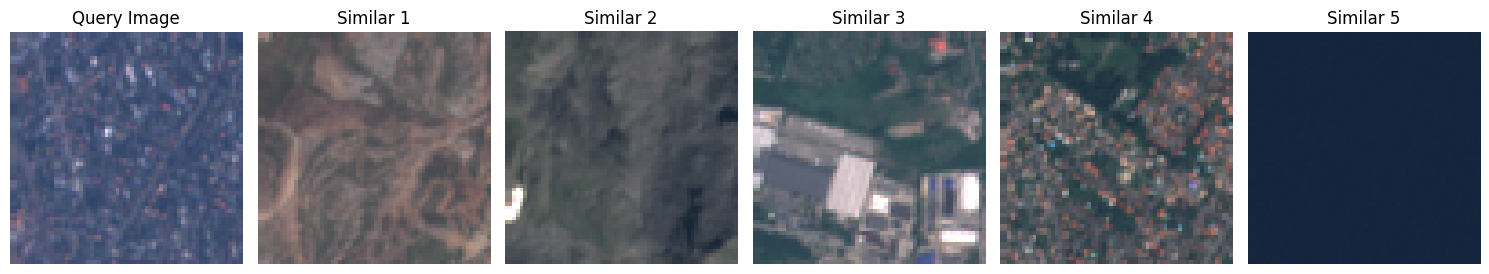

In [18]:
import faiss
from pathlib import Path
import matplotlib.pyplot as plt

def plot_similar_images(query_idx, similar_indices, image_dir, n_images=5):
    """
    Plot query image and its nearest neighbors
    
    Args:
        query_idx (int): Index of the query image
        similar_indices (np.ndarray): Indices of similar images
        image_dir (str): Directory containing the images
        n_images (int): Number of similar images to display
    """
    # Get list of image files in the same order as embeddings
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        image_files.extend(sorted(Path(image_dir).glob(f'*{ext}')))
    
    # Create a figure with n_images + 1 subplots (query + neighbors)
    fig, axes = plt.subplots(1, n_images + 1, figsize=(15, 3))
    
    # Plot query image
    query_img = Image.open(image_files[query_idx])
    axes[0].imshow(query_img)
    axes[0].set_title('Query Image')
    axes[0].axis('off')
    
    # Plot similar images
    for idx, ax in enumerate(axes[1:]):
        similar_img = Image.open(image_files[similar_indices[idx]])
        ax.imshow(similar_img)
        ax.set_title(f'Similar {idx+1}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Normalize the embeddings
embeddings_normalized = embeddings.astype('float32')
faiss.normalize_L2(embeddings_normalized)  # in-place normalization

# Create FAISS index using inner product (IP) distance
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # IP = Inner Product
index.add(embeddings_normalized)

# Example: Find similar images for a random query
k = 6  # number of nearest neighbors to retrieve
query_idx = np.random.randint(0, len(embeddings))

# Normalize query vector
query_vector = embeddings[query_idx:query_idx+1].astype('float32')
faiss.normalize_L2(query_vector)

# Search
similarities, indices = index.search(query_vector, k)

# Visualize results
plot_similar_images(query_idx, indices[0][1:], "../../data/") 

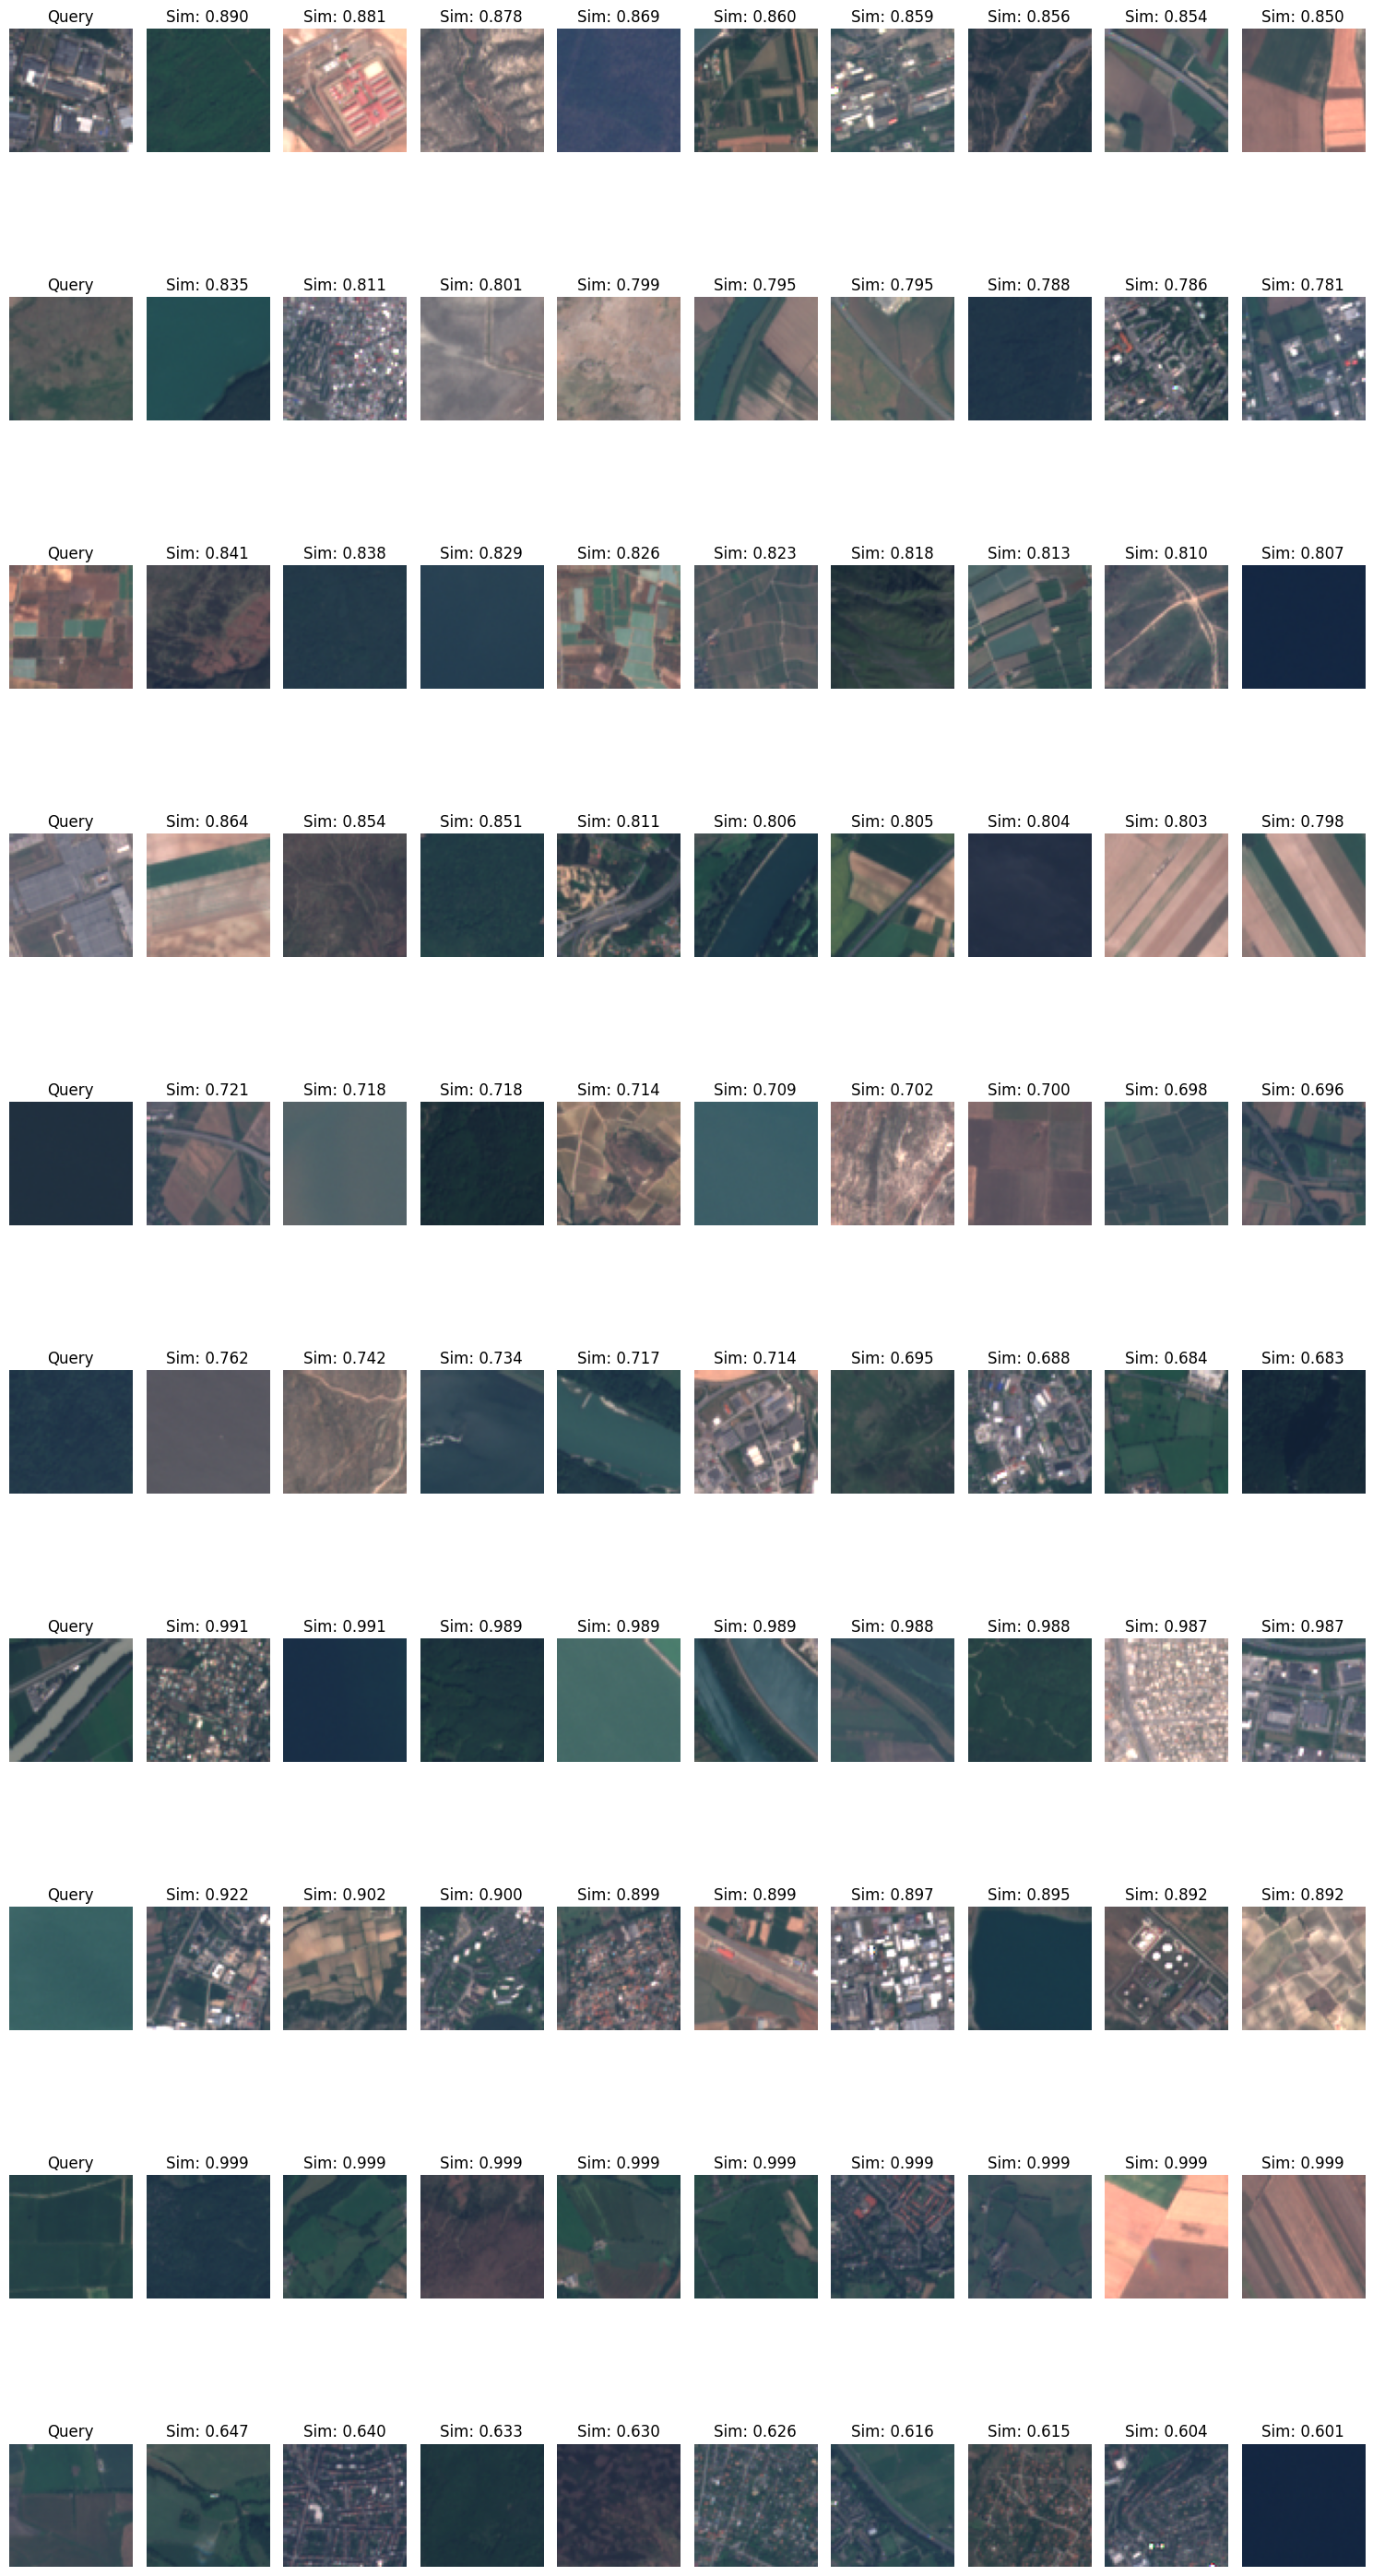

In [24]:
def plot_multiple_queries(query_indices, similar_indices, similarities, image_dir, n_neighbors=5, figsize=(15, 3)):
    """
    Plot multiple rows of query images and their nearest neighbors
    
    Args:
        query_indices (list): List of query image indices
        similar_indices (np.ndarray): Array of similar image indices for each query
        similarities (np.ndarray): Array of similarity scores
        image_dir (str): Directory containing the images
        n_neighbors (int): Number of similar images to display per query
        figsize (tuple): Base figure size for a single row (will be scaled by number of rows)
    """
    n_queries = len(query_indices)
    
    # Get list of image files in the same order as embeddings
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
        image_files.extend(sorted(Path(image_dir).glob(f'*{ext}')))
    
    # Create a figure with n_queries rows
    fig, axes = plt.subplots(n_queries, n_neighbors + 1, 
                            figsize=(figsize[0], figsize[1] * n_queries))
    if n_queries == 1:
        axes = axes[None, :]  # Add dimension for consistent indexing
    
    for row, (query_idx, sim_indices, sim_scores) in enumerate(zip(query_indices, similar_indices, similarities)):
        # Plot query image
        query_img = Image.open(image_files[query_idx])
        axes[row, 0].imshow(query_img)
        axes[row, 0].set_title('Query')
        axes[row, 0].axis('off')
        
        # Plot similar images
        for col, (idx, score) in enumerate(zip(sim_indices[1:], sim_scores[1:]), 1):
            similar_img = Image.open(image_files[idx])
            axes[row, col].imshow(similar_img)
            axes[row, col].set_title(f'Sim: {score:.3f}')
            axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage:
n_queries = 10  # Number of random queries to show
k = 10  # number of nearest neighbors to retrieve

# Generate random query indices
query_indices = np.random.choice(len(embeddings), n_queries, replace=False)

# Get similar images for all queries
all_similarities = []
all_indices = []

for idx in query_indices:
    query_vector = embeddings[idx:idx+1].astype('float32')
    faiss.normalize_L2(query_vector)
    similarities, indices = index.search(query_vector, k)
    all_similarities.append(similarities[0])
    all_indices.append(indices[0])

# Visualize results
plot_multiple_queries(
    query_indices, 
    np.array(all_indices), 
    np.array(all_similarities), 
    "../../data/",
    n_neighbors=9
)